In [10]:
# complete_conditional_gan_with_evaluation_fixed.py
# Conditional DCGAN for PlantVillage + full evaluation & visualizations
# Run in Google Colab / Jupyter. Uncomment pip installs if needed.

# !pip install -q scikit-image scipy tqdm matplotlib tensorflow

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings

from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import cosine_similarity
from scipy import linalg
from skimage.metrics import structural_similarity as ssim
from skimage.color import rgb2gray
from skimage.util import img_as_ubyte

warnings.filterwarnings("ignore")

# ================= CONFIG =================
data_root = "/teamspace/studios/this_studio/.cache/kagglehub/datasets/emmarex/plantdisease/versions/1/PlantVillage"
img_size = 64
batch_size = 64
latent_dim = 100
epochs = 200  # adjust as needed
eval_sample_count = 500  # number of samples to evaluate

# ================= LOAD DATA =================
dataset = tf.keras.utils.image_dataset_from_directory(
    data_root,
    image_size=(img_size, img_size),
    label_mode="int",
    batch_size=batch_size,
    shuffle=True
)

class_names = dataset.class_names
num_classes = len(class_names)
print("Detected classes:", num_classes)
print(class_names)

# normalize images to [-1, 1] for training
dataset = dataset.map(lambda x, y: ((x / 127.5) - 1.0, y))

Found 20638 files belonging to 15 classes.
Detected classes: 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [3]:
!pip install -q scikit-image


In [11]:
# ================= GENERATOR =================
def build_generator(latent_dim, num_classes):
    noise_input = layers.Input(shape=(latent_dim,))
    label_input = layers.Input(shape=(1,), dtype='int32')

    label_embedding = layers.Embedding(num_classes, latent_dim)(label_input)
    label_embedding = layers.Flatten()(label_embedding)
    model_input = layers.Multiply()([noise_input, label_embedding])

    x = layers.Dense(8 * 8 * 256, use_bias=False)(model_input)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Reshape((8, 8, 256))(x)

    x = layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    out = layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding="same",
                                 activation="tanh", use_bias=False)(x)

    model = tf.keras.Model([noise_input, label_input], out, name="generator")
    return model


In [12]:
# ================= DISCRIMINATOR =================
def build_discriminator(num_classes):
    img_input = layers.Input(shape=(img_size, img_size, 3))
    label_input = layers.Input(shape=(1,), dtype="int32")

    label_embedding = layers.Embedding(num_classes, img_size * img_size)(label_input)
    label_embedding = layers.Reshape((img_size, img_size, 1))(label_embedding)

    x = layers.Concatenate(axis=-1)([img_input, label_embedding])
    x = layers.Conv2D(64, (5, 5), strides=(2, 2), padding="same")(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, (5, 5), strides=(2, 2), padding="same")(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model([img_input, label_input], out, name="discriminator")
    return model


In [13]:
# ================= BUILD MODELS =================
generator = build_generator(latent_dim, num_classes)
discriminator = build_discriminator(num_classes)

cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)
gen_optimizer = tf.keras.optimizers.Adam(1e-4)
disc_optimizer = tf.keras.optimizers.Adam(1e-4)

In [14]:
# ================= TRAIN STEP =================
@tf.function
def train_step(images, labels):
    # batch may be smaller at end; use actual batch size
    batch_size_actual = tf.shape(images)[0]
    noise = tf.random.normal([batch_size_actual, latent_dim])
    fake_labels = tf.random.uniform([batch_size_actual, 1], minval=0, maxval=num_classes, dtype=tf.int32)

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator([noise, fake_labels], training=True)

        real_output = discriminator([images, tf.expand_dims(labels, 1)], training=True)
        fake_output = discriminator([generated_images, fake_labels], training=True)

        gen_loss = cross_entropy(tf.ones_like(fake_output), fake_output)
        disc_loss = (cross_entropy(tf.ones_like(real_output), real_output) +
                     cross_entropy(tf.zeros_like(fake_output), fake_output)) / 2

    grads_gen = gen_tape.gradient(gen_loss, generator.trainable_variables)
    grads_disc = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    gen_optimizer.apply_gradients(zip(grads_gen, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(grads_disc, discriminator.trainable_variables))

    return gen_loss, disc_loss

def plot_generated_images(generator, epoch, num_examples=15):
    plt.figure(figsize=(15, 3))
    noise = tf.random.normal([num_examples, latent_dim])
    labels = tf.convert_to_tensor(np.arange(num_examples).reshape(-1, 1) % num_classes, dtype=tf.int32)
    generated_images = generator([noise, labels], training=False)
    generated_images = (generated_images + 1.0) / 2.0  # scale to [0,1]

    for i in range(num_examples):
        plt.subplot(1, num_examples, i + 1)
        plt.imshow(generated_images[i])
        plt.axis("off")
    plt.suptitle(f"Generated Images - Epoch {epoch}")
    plt.show()

Epoch 1/200: 100%|██████████| 323/323 [00:23<00:00,  2.67it/s]2025-11-07 06:21:17.452668: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 1: GenLoss=2.3533 | DiscLoss=0.2345


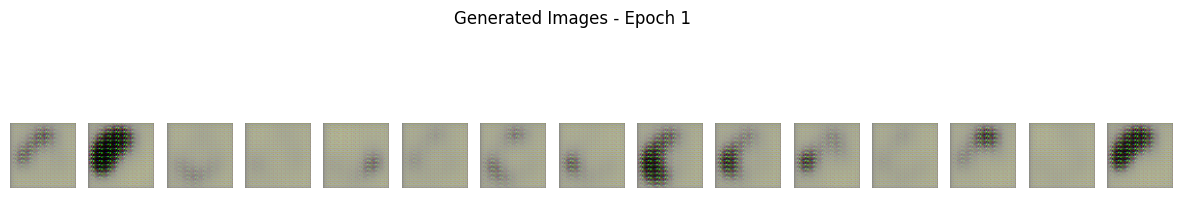

Epoch 2/200:  99%|█████████▉| 321/323 [00:18<00:00, 17.41it/s]2025-11-07 06:21:36.557621: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 2: GenLoss=2.5547 | DiscLoss=0.2645


Epoch 3: GenLoss=2.6639 | DiscLoss=0.3375


Epoch 4/200:  99%|█████████▉| 321/323 [00:18<00:00, 17.45it/s]2025-11-07 06:22:13.459318: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 4: GenLoss=2.4244 | DiscLoss=0.4245


...

Epoch 7: GenLoss=2.6012 | DiscLoss=0.3057


Epoch 8/200:  99%|█████████▉| 321/323 [00:18<00:00, 18.18it/s]2025-11-07 06:23:27.955229: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 8: GenLoss=2.1996 | DiscLoss=0.3933


Epoch 9: GenLoss=2.1335 | DiscLoss=0.3691


Epoch 10: GenLoss=2.0997 | DiscLoss=0.3725


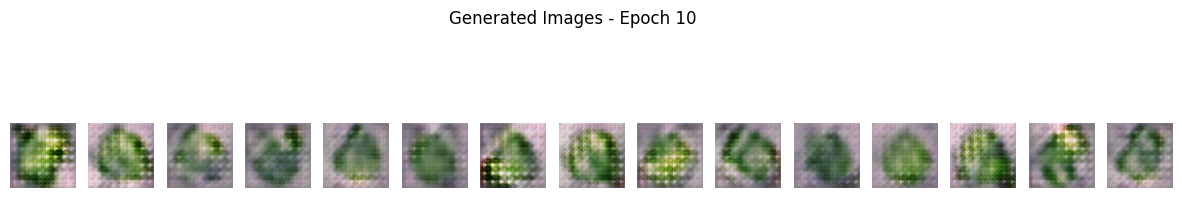

Epoch 11: GenLoss=2.1399 | DiscLoss=0.3871


Epoch 12: GenLoss=2.2992 | DiscLoss=0.3900


Epoch 13: GenLoss=2.0743 | DiscLoss=0.3620


Epoch 14: GenLoss=2.3119 | DiscLoss=0.3479


Epoch 15: GenLoss=2.4288 | DiscLoss=0.3144


...

Epoch 16: GenLoss=2.4953 | DiscLoss=0.2991


Epoch 17: GenLoss=2.2422 | DiscLoss=0.3636


Epoch 18: GenLoss=2.4338 | DiscLoss=0.3513


Epoch 19: GenLoss=2.3539 | DiscLoss=0.3258


Epoch 20: GenLoss=2.5778 | DiscLoss=0.3051


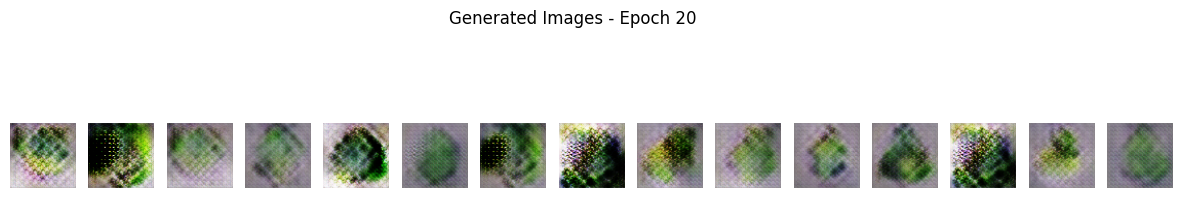

Epoch 21: GenLoss=2.3150 | DiscLoss=0.3693


Epoch 22: GenLoss=2.5028 | DiscLoss=0.3777


Epoch 23: GenLoss=2.6667 | DiscLoss=0.3401


Epoch 24: GenLoss=2.7422 | DiscLoss=0.3660


Epoch 25: GenLoss=2.6199 | DiscLoss=0.3106


Epoch 26: GenLoss=2.3652 | DiscLoss=0.3808


Epoch 27: GenLoss=2.3343 | DiscLoss=0.4279


Epoch 28: GenLoss=2.3789 | DiscLoss=0.4041


Epoch 29: GenLoss=2.2137 | DiscLoss=0.3834


Epoch 30: GenLoss=2.2077 | DiscLoss=0.4211


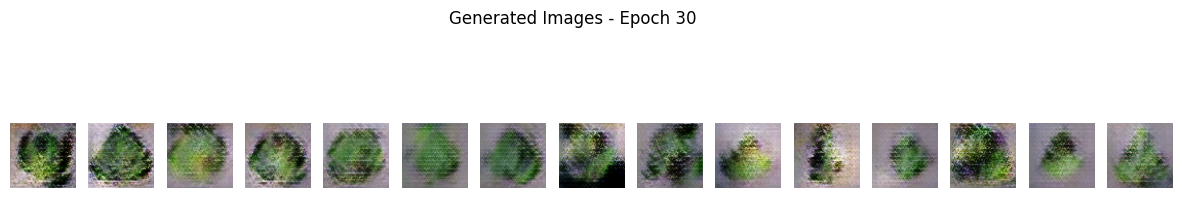

Epoch 31: GenLoss=2.3809 | DiscLoss=0.3927


Epoch 32/200: 100%|█████████▉| 322/323 [00:18<00:00, 17.43it/s]2025-11-07 06:31:04.562701: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 32: GenLoss=2.3054 | DiscLoss=0.4058


Epoch 33: GenLoss=2.3365 | DiscLoss=0.3933


Epoch 34: GenLoss=2.1648 | DiscLoss=0.4427


...

Epoch 36: GenLoss=2.1985 | DiscLoss=0.4315


Epoch 37: GenLoss=2.1275 | DiscLoss=0.4403


Epoch 38: GenLoss=1.9959 | DiscLoss=0.4490


Epoch 39: GenLoss=2.0386 | DiscLoss=0.4528


Epoch 40: GenLoss=2.0664 | DiscLoss=0.4420


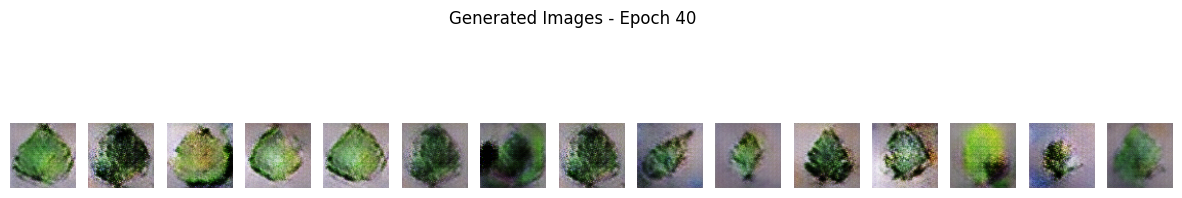

Epoch 41: GenLoss=2.0774 | DiscLoss=0.4743


Epoch 42: GenLoss=2.1246 | DiscLoss=0.4229


Epoch 43: GenLoss=2.0501 | DiscLoss=0.4362


Epoch 44: GenLoss=1.9741 | DiscLoss=0.4621


Epoch 45: GenLoss=1.8548 | DiscLoss=0.4953


Epoch 46: GenLoss=1.8597 | DiscLoss=0.4852


Epoch 47: GenLoss=2.0380 | DiscLoss=0.4768


Epoch 48: GenLoss=1.9713 | DiscLoss=0.4892


Epoch 49: GenLoss=1.8636 | DiscLoss=0.5072


Epoch 50: GenLoss=1.8456 | DiscLoss=0.4928


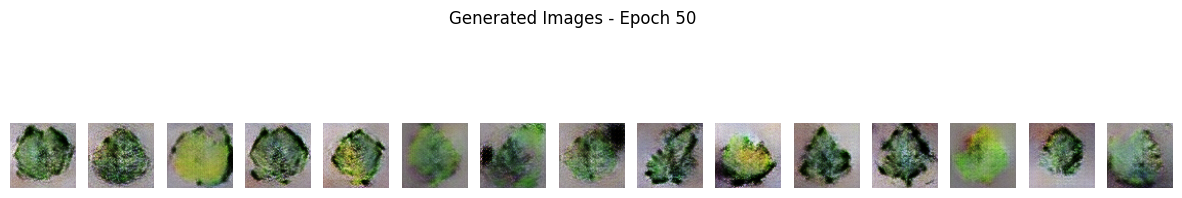

Epoch 51: GenLoss=1.7871 | DiscLoss=0.5215


Epoch 52: GenLoss=1.8227 | DiscLoss=0.4875


Epoch 53: GenLoss=1.8590 | DiscLoss=0.4779


Epoch 54: GenLoss=1.7843 | DiscLoss=0.5212


Epoch 55: GenLoss=1.6426 | DiscLoss=0.5169


Epoch 56: GenLoss=1.6800 | DiscLoss=0.5429


Epoch 57: GenLoss=1.6901 | DiscLoss=0.5017


Epoch 58: GenLoss=1.7190 | DiscLoss=0.5246


Epoch 59: GenLoss=1.6040 | DiscLoss=0.5365


Epoch 60: GenLoss=1.6668 | DiscLoss=0.5335


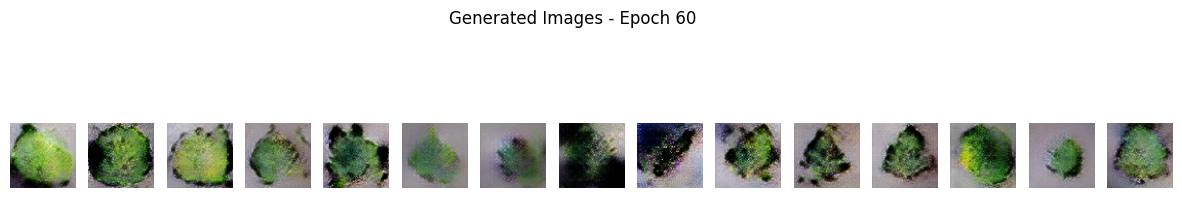

Epoch 61: GenLoss=1.6573 | DiscLoss=0.5274


Epoch 62: GenLoss=1.6537 | DiscLoss=0.5372


Epoch 63: GenLoss=1.6392 | DiscLoss=0.5376


Epoch 64/200: 100%|█████████▉| 322/323 [00:18<00:00, 17.68it/s]2025-11-07 06:40:59.154268: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 64: GenLoss=1.5344 | DiscLoss=0.5752


...

Epoch 66: GenLoss=1.6208 | DiscLoss=0.5149


Epoch 67: GenLoss=1.6198 | DiscLoss=0.5345


Epoch 68: GenLoss=1.5562 | DiscLoss=0.5581


Epoch 69: GenLoss=1.5034 | DiscLoss=0.5696


Epoch 70: GenLoss=1.4273 | DiscLoss=0.5642


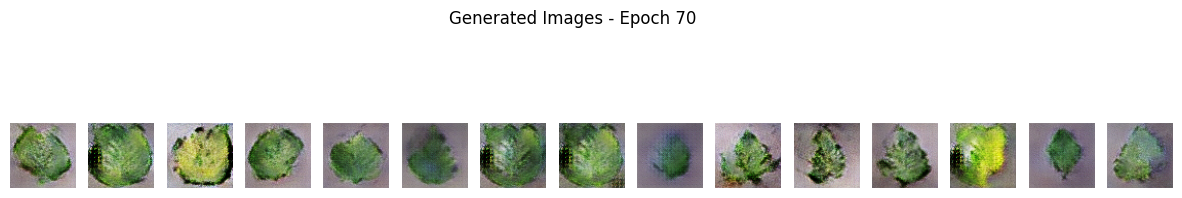

Epoch 71: GenLoss=1.5123 | DiscLoss=0.5477


Epoch 72: GenLoss=1.5549 | DiscLoss=0.5320


Epoch 73: GenLoss=1.5215 | DiscLoss=0.5563


Epoch 74: GenLoss=1.4564 | DiscLoss=0.5536


Epoch 75: GenLoss=1.5131 | DiscLoss=0.5463


Epoch 76: GenLoss=1.4883 | DiscLoss=0.5555


Epoch 77: GenLoss=1.4609 | DiscLoss=0.5466


Epoch 78: GenLoss=1.4826 | DiscLoss=0.5756


Epoch 79: GenLoss=1.5065 | DiscLoss=0.5418


Epoch 80: GenLoss=1.4050 | DiscLoss=0.5642


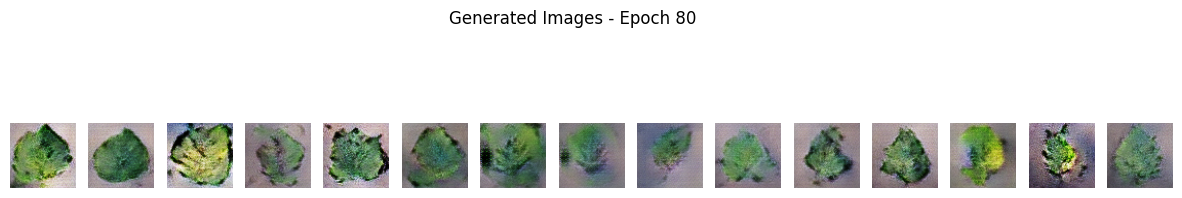

Epoch 81: GenLoss=1.4296 | DiscLoss=0.5482


Epoch 82: GenLoss=1.3905 | DiscLoss=0.5633


Epoch 83: GenLoss=1.3994 | DiscLoss=0.5791


Epoch 84: GenLoss=1.4150 | DiscLoss=0.5731


Epoch 85: GenLoss=1.3394 | DiscLoss=0.5770


Epoch 86: GenLoss=1.3795 | DiscLoss=0.5579


Epoch 87: GenLoss=1.4061 | DiscLoss=0.5759


Epoch 88: GenLoss=1.4663 | DiscLoss=0.5699


Epoch 89: GenLoss=1.3373 | DiscLoss=0.5733


Epoch 90: GenLoss=1.3251 | DiscLoss=0.5718


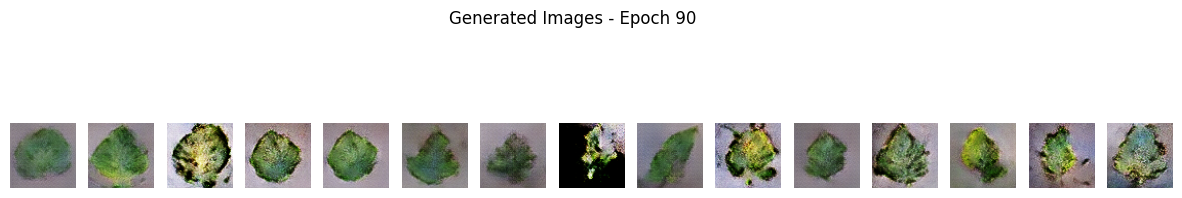

Epoch 91: GenLoss=1.3693 | DiscLoss=0.5715


Epoch 92: GenLoss=1.3793 | DiscLoss=0.5553


Epoch 93: GenLoss=1.4071 | DiscLoss=0.5475


Epoch 94: GenLoss=1.4337 | DiscLoss=0.5424


Epoch 95: GenLoss=1.4228 | DiscLoss=0.5672


Epoch 96: GenLoss=1.3712 | DiscLoss=0.5650


Epoch 97: GenLoss=1.3439 | DiscLoss=0.5685


Epoch 98: GenLoss=1.3706 | DiscLoss=0.5706


Epoch 99: GenLoss=1.4739 | DiscLoss=0.5337


Epoch 100: GenLoss=1.3918 | DiscLoss=0.5600


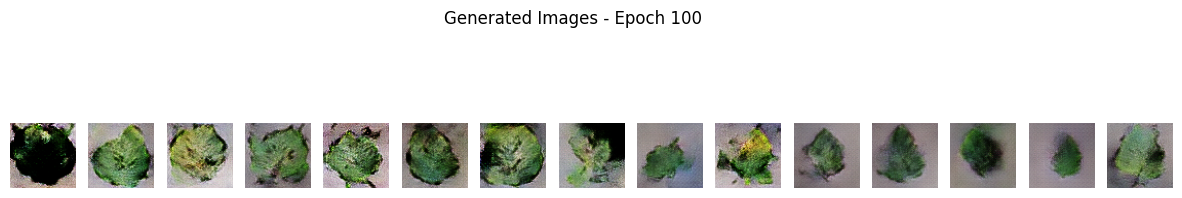

Epoch 101: GenLoss=1.3284 | DiscLoss=0.5550


Epoch 102: GenLoss=1.3862 | DiscLoss=0.5639


Epoch 103: GenLoss=1.3815 | DiscLoss=0.5682


Epoch 104: GenLoss=1.3636 | DiscLoss=0.5522


Epoch 105: GenLoss=1.3903 | DiscLoss=0.5436


Epoch 106: GenLoss=1.4087 | DiscLoss=0.5619


Epoch 107: GenLoss=1.3869 | DiscLoss=0.5516


Epoch 108: GenLoss=1.4233 | DiscLoss=0.5413


Epoch 109: GenLoss=1.3073 | DiscLoss=0.5670


Epoch 110: GenLoss=1.3862 | DiscLoss=0.5399


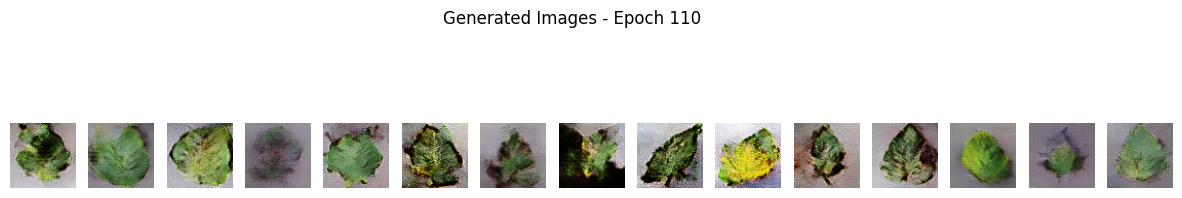

Epoch 111: GenLoss=1.3730 | DiscLoss=0.5543


Epoch 112: GenLoss=1.3460 | DiscLoss=0.5560


Epoch 113: GenLoss=1.4252 | DiscLoss=0.5364


Epoch 114: GenLoss=1.3847 | DiscLoss=0.5330


Epoch 115: GenLoss=1.3906 | DiscLoss=0.5545


Epoch 116: GenLoss=1.3813 | DiscLoss=0.5565


Epoch 117: GenLoss=1.3747 | DiscLoss=0.5501


Epoch 118: GenLoss=1.3207 | DiscLoss=0.5580


Epoch 119: GenLoss=1.3660 | DiscLoss=0.5391


Epoch 120: GenLoss=1.4245 | DiscLoss=0.5535


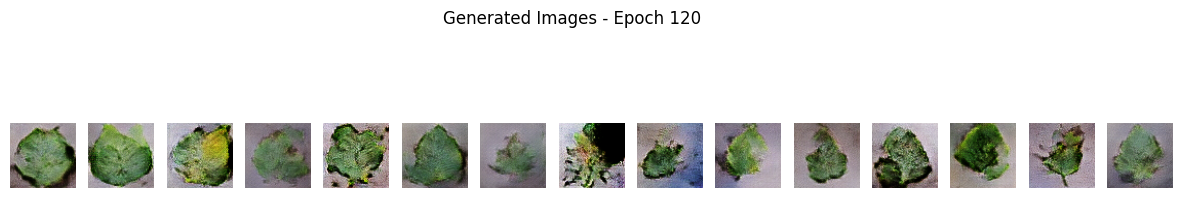

Epoch 121: GenLoss=1.3457 | DiscLoss=0.5681


Epoch 122: GenLoss=1.3650 | DiscLoss=0.5484


Epoch 123: GenLoss=1.3964 | DiscLoss=0.5550


Epoch 124: GenLoss=1.3600 | DiscLoss=0.5557


Epoch 125: GenLoss=1.3351 | DiscLoss=0.5541


...

Epoch 127: GenLoss=1.3731 | DiscLoss=0.5566


Epoch 128/200: 100%|█████████▉| 322/323 [00:18<00:00, 17.56it/s]2025-11-07 07:00:43.951055: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 128: GenLoss=1.4059 | DiscLoss=0.5521


Epoch 129: GenLoss=1.2949 | DiscLoss=0.5613


Epoch 130: GenLoss=1.3375 | DiscLoss=0.5479


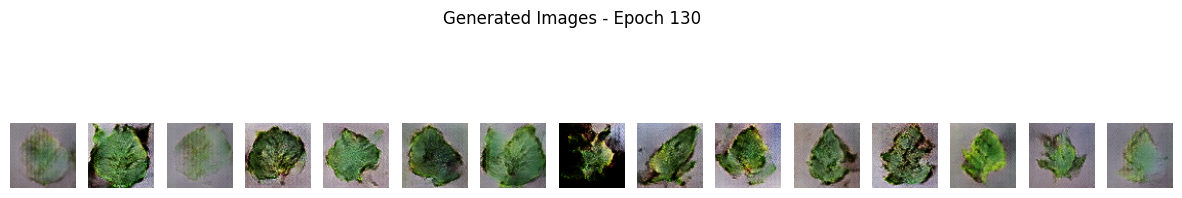

Epoch 131: GenLoss=1.3837 | DiscLoss=0.5622


Epoch 132: GenLoss=1.3953 | DiscLoss=0.5360


Epoch 133: GenLoss=1.3501 | DiscLoss=0.5555


Epoch 134: GenLoss=1.3614 | DiscLoss=0.5512


Epoch 135: GenLoss=1.3082 | DiscLoss=0.5742


Epoch 136: GenLoss=1.3448 | DiscLoss=0.5442


Epoch 137: GenLoss=1.3867 | DiscLoss=0.5649


Epoch 138: GenLoss=1.3258 | DiscLoss=0.5543


Epoch 139: GenLoss=1.3273 | DiscLoss=0.5588


Epoch 140: GenLoss=1.3164 | DiscLoss=0.5475


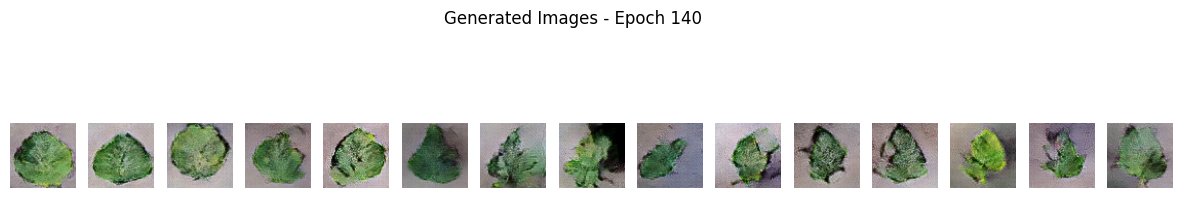

Epoch 141: GenLoss=1.3564 | DiscLoss=0.5471


Epoch 142: GenLoss=1.3989 | DiscLoss=0.5428


Epoch 143: GenLoss=1.3538 | DiscLoss=0.5578


Epoch 144: GenLoss=1.3154 | DiscLoss=0.5455


Epoch 145: GenLoss=1.3269 | DiscLoss=0.5643


Epoch 146: GenLoss=1.3365 | DiscLoss=0.5482


Epoch 147: GenLoss=1.3723 | DiscLoss=0.5571


Epoch 148: GenLoss=1.3077 | DiscLoss=0.5442


Epoch 149: GenLoss=1.3591 | DiscLoss=0.5575


Epoch 150: GenLoss=1.3085 | DiscLoss=0.5631


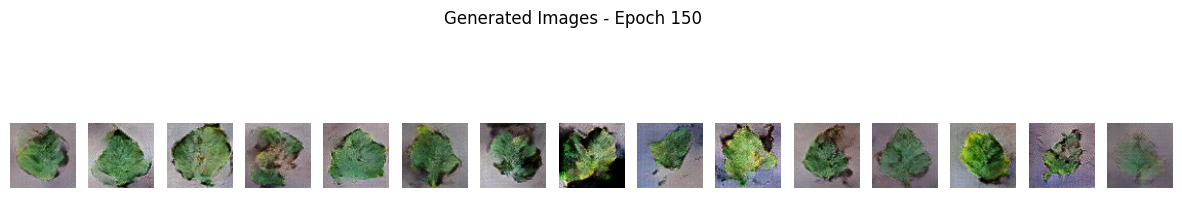

Epoch 151: GenLoss=1.3618 | DiscLoss=0.5407


Epoch 152: GenLoss=1.3558 | DiscLoss=0.5566


Epoch 153: GenLoss=1.3488 | DiscLoss=0.5450


Epoch 154: GenLoss=1.3267 | DiscLoss=0.5587


Epoch 155: GenLoss=1.3861 | DiscLoss=0.5461


Epoch 156: GenLoss=1.4295 | DiscLoss=0.5426


Epoch 157: GenLoss=1.3637 | DiscLoss=0.5538


Epoch 158: GenLoss=1.3287 | DiscLoss=0.5494


Epoch 159: GenLoss=1.3155 | DiscLoss=0.5614


Epoch 160: GenLoss=1.3614 | DiscLoss=0.5377


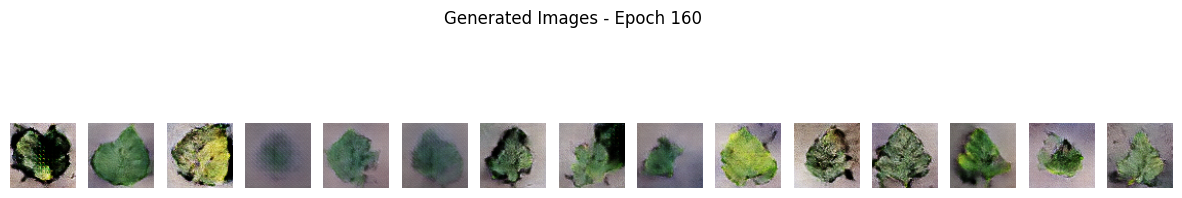

Epoch 161: GenLoss=1.3360 | DiscLoss=0.5645


Epoch 162: GenLoss=1.3174 | DiscLoss=0.5403


Epoch 163: GenLoss=1.3251 | DiscLoss=0.5568


Epoch 164: GenLoss=1.2969 | DiscLoss=0.5548


Epoch 165: GenLoss=1.3289 | DiscLoss=0.5565


Epoch 166: GenLoss=1.2922 | DiscLoss=0.5530


Epoch 167: GenLoss=1.3431 | DiscLoss=0.5549


Epoch 168: GenLoss=1.2976 | DiscLoss=0.5841


Epoch 169: GenLoss=1.3136 | DiscLoss=0.5473


Epoch 170: GenLoss=1.2815 | DiscLoss=0.5590


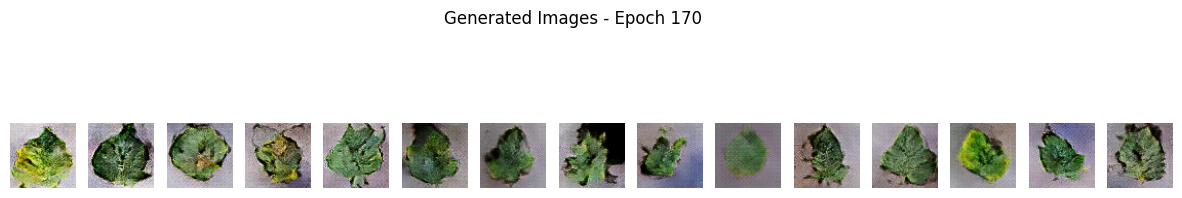

Epoch 171: GenLoss=1.3496 | DiscLoss=0.5457


Epoch 172: GenLoss=1.3003 | DiscLoss=0.5630


Epoch 173: GenLoss=1.3829 | DiscLoss=0.5490


Epoch 174: GenLoss=1.3313 | DiscLoss=0.5542


Epoch 175: GenLoss=1.3159 | DiscLoss=0.5665


Epoch 176: GenLoss=1.2981 | DiscLoss=0.5625


Epoch 177: GenLoss=1.2887 | DiscLoss=0.5528


Epoch 178: GenLoss=1.2930 | DiscLoss=0.5627


Epoch 179: GenLoss=1.3492 | DiscLoss=0.5476


Epoch 180: GenLoss=1.2544 | DiscLoss=0.5699


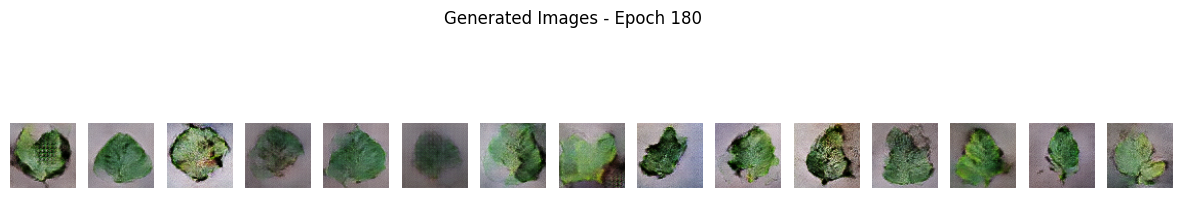

Epoch 181: GenLoss=1.3149 | DiscLoss=0.5566


Epoch 182: GenLoss=1.2855 | DiscLoss=0.5542


Epoch 183: GenLoss=1.3598 | DiscLoss=0.5677


Epoch 184: GenLoss=1.2955 | DiscLoss=0.5590


Epoch 185: GenLoss=1.2600 | DiscLoss=0.5735


Epoch 186: GenLoss=1.2878 | DiscLoss=0.5678


Epoch 187: GenLoss=1.3082 | DiscLoss=0.5511


Epoch 188: GenLoss=1.3390 | DiscLoss=0.5551


Epoch 189: GenLoss=1.3297 | DiscLoss=0.5611


Epoch 190: GenLoss=1.2972 | DiscLoss=0.5644


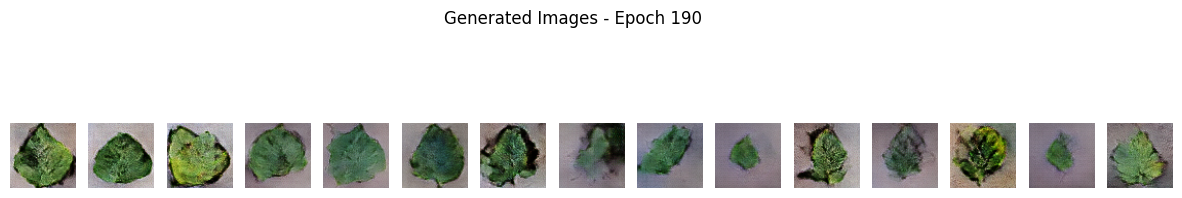

Epoch 191: GenLoss=1.3422 | DiscLoss=0.5415


Epoch 192: GenLoss=1.2661 | DiscLoss=0.5624


Epoch 193: GenLoss=1.3008 | DiscLoss=0.5524


Epoch 194: GenLoss=1.3602 | DiscLoss=0.5556


Epoch 195: GenLoss=1.3573 | DiscLoss=0.5537


Epoch 196: GenLoss=1.3614 | DiscLoss=0.5564


Epoch 197: GenLoss=1.3141 | DiscLoss=0.5771


Epoch 198: GenLoss=1.3298 | DiscLoss=0.5643


Epoch 199: GenLoss=1.2842 | DiscLoss=0.5738


Epoch 200: GenLoss=1.3051 | DiscLoss=0.5465


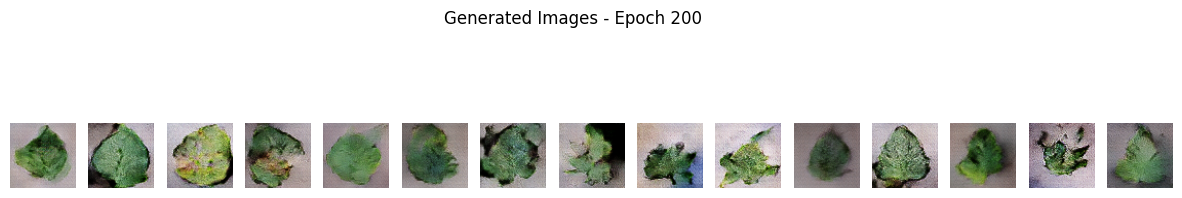

In [15]:
# ================= TRAIN LOOP =================
for epoch in range(1, epochs+1):
    gen_losses, disc_losses = [], []
    for image_batch, label_batch in tqdm(dataset, desc=f"Epoch {epoch}/{epochs}", leave=False):
        g_loss, d_loss = train_step(image_batch, label_batch)
        gen_losses.append(g_loss.numpy())
        disc_losses.append(d_loss.numpy())

    print(f"Epoch {epoch}: GenLoss={np.mean(gen_losses):.4f} | DiscLoss={np.mean(disc_losses):.4f}")
    if epoch % 10 == 0 or epoch == 1:
        plot_generated_images(generator, epoch)

In [16]:
# ================= SAVE MODELS =================
os.makedirs("saved_conditional_gan_models", exist_ok=True)
generator.save("saved_conditional_gan_models/plant_cgan_generator.keras")
discriminator.save("saved_conditional_gan_models/plant_cgan_discriminator.keras")
print("✅ Conditional GAN training complete! Models saved to saved_conditional_gan_models/")

✅ Conditional GAN training complete! Models saved to saved_conditional_gan_models/


In [17]:

# ================= EVALUATION UTILITIES =================

def get_eval_samples_from_dataset(ds, n_samples=500):
    """
    Collect n_samples images and labels from the tf.data dataset.
    Input ds: dataset normalized to [-1,1] (as used for training).
    Returns arrays in range [0,1], dtype float32.
    """
    images = []
    labels = []
    count = 0
    for batch_images, batch_labels in ds.unbatch():
        img = batch_images.numpy()  # in [-1,1]
        img = (img + 1.0) / 2.0  # convert to [0,1]
        images.append(img)
        labels.append(int(batch_labels.numpy()))
        count += 1
        if count >= n_samples:
            break
    images = np.stack(images, axis=0)
    labels = np.array(labels, dtype=np.int32)
    return images, labels

real_images, real_labels = get_eval_samples_from_dataset(dataset, n_samples=eval_sample_count)
print(f"Sampled {len(real_images)} real images for evaluation.")

def generate_images_for_labels(generator, labels):
    """
    Given shape (N,) integer labels, generate N images using generator.
    Returns images in [0,1] float32.
    """
    n = len(labels)
    noise = tf.random.normal([n, latent_dim])
    labels_tensor = tf.convert_to_tensor(labels.reshape(-1,1), dtype=tf.int32)
    generated = generator([noise, labels_tensor], training=False)
    generated = (generated + 1.0) / 2.0
    return generated.numpy()

gen_images = generate_images_for_labels(generator, real_labels)
print(f"Generated {len(gen_images)} images for evaluation.")

# helper: convert to uint8 [0,255] for some metrics if needed
def to_uint8(images):
    images_clipped = np.clip(images, 0.0, 1.0)
    return (images_clipped * 255).astype(np.uint8)


Sampled 500 real images for evaluation.
Generated 500 images for evaluation.


In [20]:
# ================= METRIC COMPUTATIONS =================

# Pixel-wise MSE, MAE
def compute_pixel_metrics(real, gen):
    # real, gen: arrays [N, H, W, C], floats in [0,1]
    mse_list = np.mean((real - gen) ** 2, axis=(1,2,3))
    mae_list = np.mean(np.abs(real - gen), axis=(1,2,3))
    return mse_list, mae_list

# SSIM per image (use channel_axis argument)
def compute_ssim_list(real, gen):
    n = real.shape[0]
    ssim_list = []
    for i in range(n):
        # skimage structural_similarity expects channel_axis=-1 for color images
        s = ssim(real[i], gen[i], channel_axis=-1, data_range=1.0)
        ssim_list.append(s)
    return np.array(ssim_list)

# Entropy of grayscale histogram (Shannon entropy)
def compute_entropy_list(images, nbins=256):
    entropies = []
    for img in images:
        gray = rgb2gray(img)  # floats in [0,1]
        hist, _ = np.histogram(img_as_ubyte(gray), bins=nbins, range=(0,255), density=True)
        hist = hist + 1e-12
        ent = -np.sum(hist * np.log2(hist))
        entropies.append(ent)
    return np.array(entropies)

# --- Drop-in replacement for get_inception_embeddings (use instead of your old version) ---
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input

# cache the model so we only build it once
_inception_model = None

def get_inception_embeddings(images, batch_size=32, target_size=(299, 299)):
    """
    Compute InceptionV3 'pooling=avg' embeddings for a set of images.
    - images: numpy array or list of images in range [0,1], shape (N, H, W, 3)
    - returns: numpy array (N, 2048)
    """
    global _inception_model
    if _inception_model is None:
        # build model once with imagenet default input size 299x299
        _inception_model = InceptionV3(include_top=False, pooling='avg', input_shape=(299, 299, 3))
        # warmup (optional) to avoid slow first-call overhead
        # _inception_model.predict(np.zeros((1,299,299,3), dtype=np.float32))

    imgs = np.array(images).astype(np.float32)  # expect [0,1]
    n = imgs.shape[0]
    embeddings = []

    # resize and preprocess in batches
    for start in range(0, n, batch_size):
        end = min(n, start + batch_size)
        batch = imgs[start:end]  # shape (b, H, W, 3)
        # resize to target_size using tf (keeps dtype float32)
        batch_resized = tf.image.resize(batch, target_size, method='bilinear').numpy()
        # Convert to 0..255 then preprocess_input (which scales to [-1,1])
        batch_resized = batch_resized * 255.0
        batch_pre = preprocess_input(batch_resized)
        emb_batch = _inception_model.predict(batch_pre, verbose=0)
        embeddings.append(emb_batch)

    embeddings = np.concatenate(embeddings, axis=0)
    return embeddings  # shape (N, 2048)

# FID calculation
def calculate_fid(mu1, sigma1, mu2, sigma2, eps=1e-6):
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = np.sum((mu1 - mu2) ** 2) + np.trace(sigma1 + sigma2 - 2 * covmean)
    return float(np.real(fid))

In [21]:
# ================= RUN EVALUATION =================
print("Computing pixel metrics (MSE, MAE)...")
mse_list, mae_list = compute_pixel_metrics(real_images, gen_images)
mse_mean = float(mse_list.mean())
mae_mean = float(mae_list.mean())

print("Computing SSIM per image...")
ssim_list = compute_ssim_list(real_images, gen_images)
ssim_mean = float(ssim_list.mean())

print("Computing entropy for generated images...")
entropy_gen = compute_entropy_list(gen_images)
entropy_gen_mean = float(entropy_gen.mean())

print("Computing Inception embeddings (this can take a while)...")
emb_real = get_inception_embeddings(real_images)
emb_gen = get_inception_embeddings(gen_images)

print("Computing cosine similarities (matching pairs)...")
cosine_sims = np.diag(cosine_similarity(emb_real, emb_gen))
cosine_mean = float(cosine_sims.mean())

print("Computing FID...")
mu_real = np.mean(emb_real, axis=0)
mu_gen = np.mean(emb_gen, axis=0)
sigma_real = np.cov(emb_real, rowvar=False)
sigma_gen = np.cov(emb_gen, rowvar=False)
fid_value = calculate_fid(mu_real, sigma_real, mu_gen, sigma_gen)

print("Computing average pairwise embedding distances (dataset diversity)...")
pairwise_real = pairwise_distances(emb_real, metric='euclidean')
pairwise_gen = pairwise_distances(emb_gen, metric='euclidean')

def average_pairwise(dist_matrix):
    n = dist_matrix.shape[0]
    if n <= 1:
        return 0.0
    triu_idx = np.triu_indices(n, k=1)
    vals = dist_matrix[triu_idx]
    return float(vals.mean())

avg_pairwise_real = average_pairwise(pairwise_real)
avg_pairwise_gen = average_pairwise(pairwise_gen)

Computing pixel metrics (MSE, MAE)...
Computing SSIM per image...
Computing entropy for generated images...
Computing Inception embeddings (this can take a while)...
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


2025-11-07 07:28:17.889798: I external/local_xla/xla/service/service.cc:163] XLA service 0x7b1ea00feb20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-07 07:28:17.890424: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2025-11-07 07:28:18.141175: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1762500508.992731   10229 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Computing cosine similarities (matching pairs)...
Computing FID...
Computing average pairwise embedding distances (dataset diversity)...


In [22]:
# ================= SUMMARY & PRINT =================
print("\n--- Evaluation Summary ---")
print(f"Samples used: {eval_sample_count}")
print(f"MSE (mean): {mse_mean:.6f}")
print(f"MAE (mean): {mae_mean:.6f}")
print(f"SSIM (mean): {ssim_mean:.6f}")
print(f"FID: {fid_value:.4f}")
print(f"Cosine similarity (mean): {cosine_mean:.6f}")
print(f"Reconstruction entropy (mean): {entropy_gen_mean:.4f}")
print(f"Avg pairwise embedding distance (originals): {avg_pairwise_real:.4f}")
print(f"Avg pairwise embedding distance (reconstructions): {avg_pairwise_gen:.4f}")


--- Evaluation Summary ---
Samples used: 500
MSE (mean): 0.054514
MAE (mean): 0.177753
SSIM (mean): 0.134035
FID: 6257774519299541257016665154793609710750110905341756161954223460416659352872970361395396739072.0000
Cosine similarity (mean): 0.670355
Reconstruction entropy (mean): 6.9987
Avg pairwise embedding distance (originals): 16.7923
Avg pairwise embedding distance (reconstructions): 16.6903


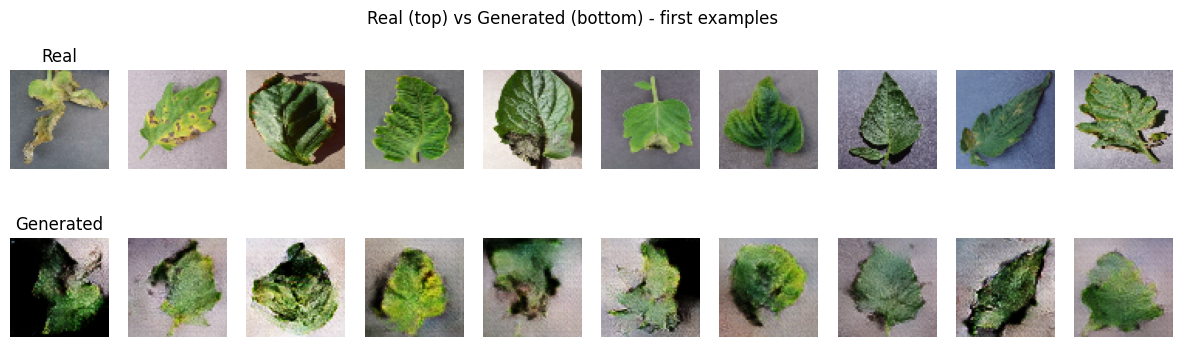

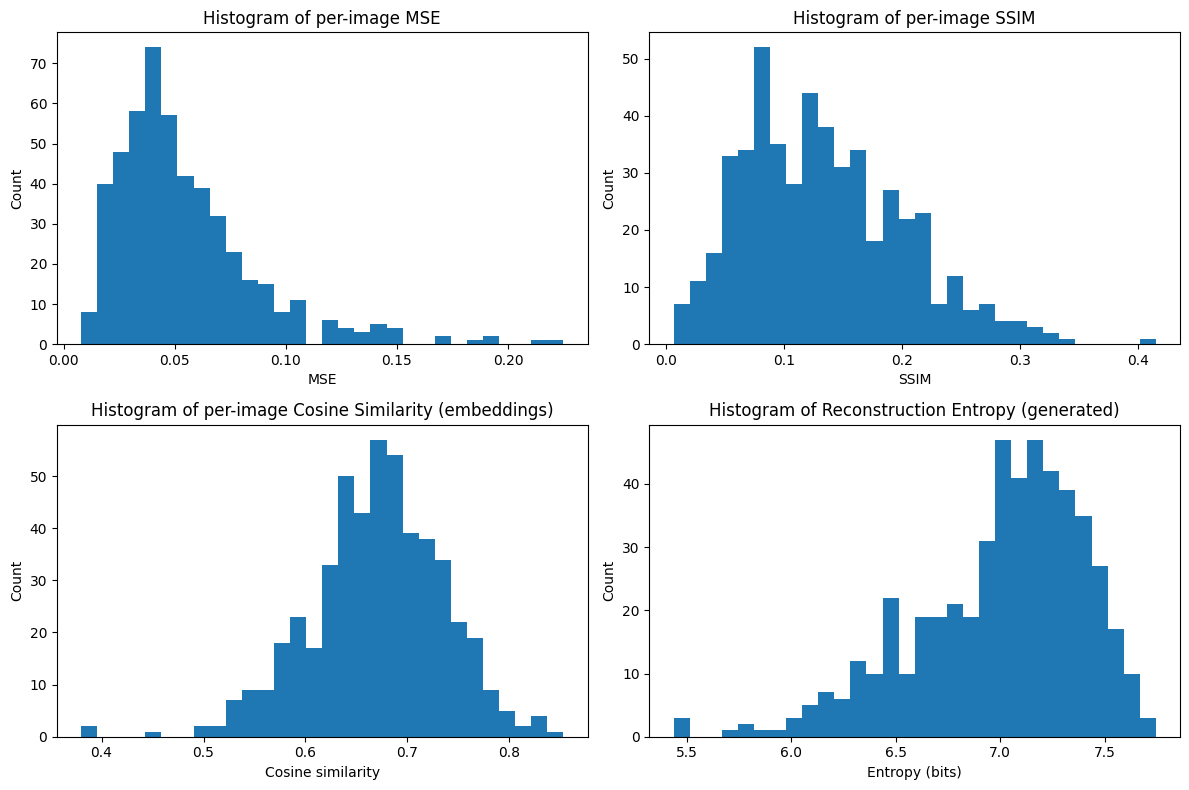

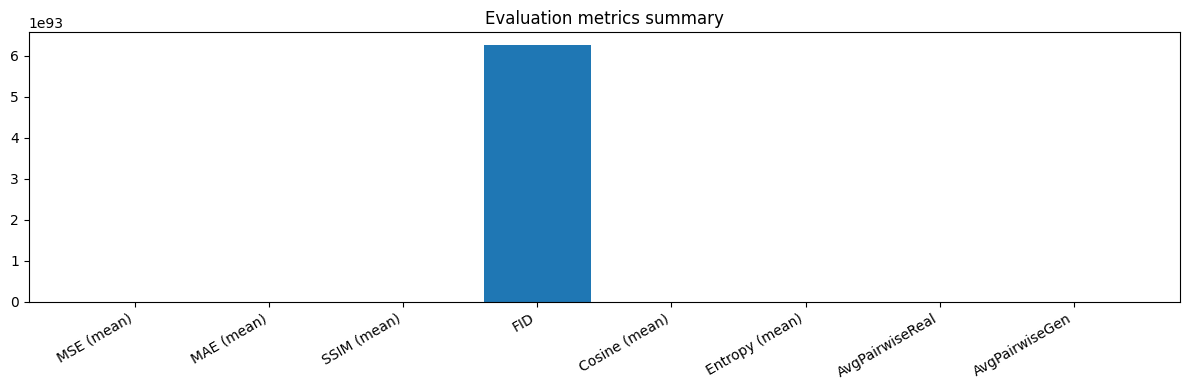


Metrics (dict):
{'Avg pairwise embedding distance (originals)': 16.792348861694336,
 'Avg pairwise embedding distance (reconstructions)': 16.690263748168945,
 'Cosine similarity (mean)': 0.6703547239303589,
 'FID': 6.257774519299541e+93,
 'MAE (mean)': 0.1777530461549759,
 'MSE (mean)': 0.05451366677880287,
 'Reconstruction entropy (mean)': 6.9987105122364985,
 'SSIM (mean)': 0.1340353935956955,
 'Samples used': 500}
✅ Evaluation complete. Artifacts saved to ./evaluation_results/


In [23]:
# ================= PLOTTING VISUALIZATIONS =================

# 1) Grid: show side-by-side real and generated examples
def plot_real_vs_generated(real, gen, n=10):
    n = min(n, real.shape[0])
    plt.figure(figsize=(15, 4))
    for i in range(n):
        plt.subplot(2, n, i+1)
        plt.imshow(real[i])
        plt.axis('off')
        if i == 0:
            plt.title('Real')
        plt.subplot(2, n, n + i+1)
        plt.imshow(gen[i])
        plt.axis('off')
        if i == 0:
            plt.title('Generated')
    plt.suptitle("Real (top) vs Generated (bottom) - first examples")
    plt.show()

plot_real_vs_generated(real_images, gen_images, n=10)

# 2) Histograms for MSE, SSIM, Cosine similarity, Entropy
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.hist(mse_list, bins=30)
plt.title("Histogram of per-image MSE")
plt.xlabel("MSE")
plt.ylabel("Count")

plt.subplot(2,2,2)
plt.hist(ssim_list, bins=30)
plt.title("Histogram of per-image SSIM")
plt.xlabel("SSIM")
plt.ylabel("Count")

plt.subplot(2,2,3)
plt.hist(cosine_sims, bins=30)
plt.title("Histogram of per-image Cosine Similarity (embeddings)")
plt.xlabel("Cosine similarity")
plt.ylabel("Count")

plt.subplot(2,2,4)
plt.hist(entropy_gen, bins=30)
plt.title("Histogram of Reconstruction Entropy (generated)")
plt.xlabel("Entropy (bits)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# 3) Bar summary of the important scalar metrics (scaled/normalized for readability)
labels = ["MSE (mean)", "MAE (mean)", "SSIM (mean)", "FID", "Cosine (mean)", "Entropy (mean)", "AvgPairwiseReal", "AvgPairwiseGen"]
values = [mse_mean, mae_mean, ssim_mean, fid_value, cosine_mean, entropy_gen_mean, avg_pairwise_real, avg_pairwise_gen]

plt.figure(figsize=(12,4))
plt.bar(range(len(values)), values)
plt.xticks(range(len(values)), labels, rotation=30, ha='right')
plt.title("Evaluation metrics summary")
plt.tight_layout()
plt.show()

# 4) Print tabular summary
from pprint import pprint
metrics_summary = {
    "Samples used": eval_sample_count,
    "MSE (mean)": mse_mean,
    "MAE (mean)": mae_mean,
    "SSIM (mean)": ssim_mean,
    "FID": fid_value,
    "Cosine similarity (mean)": cosine_mean,
    "Reconstruction entropy (mean)": entropy_gen_mean,
    "Avg pairwise embedding distance (originals)": avg_pairwise_real,
    "Avg pairwise embedding distance (reconstructions)": avg_pairwise_gen
}
print("\nMetrics (dict):")
pprint(metrics_summary)

# ================= Save evaluation artifacts (optional) =================
os.makedirs("evaluation_results", exist_ok=True)
np.save("evaluation_results/real_images.npy", real_images)
np.save("evaluation_results/generated_images.npy", gen_images)
np.save("evaluation_results/emb_real.npy", emb_real)
np.save("evaluation_results/emb_gen.npy", emb_gen)
with open("evaluation_results/metrics_summary.txt", "w") as f:
    for k,v in metrics_summary.items():
        f.write(f"{k}: {v}\n")

print("✅ Evaluation complete. Artifacts saved to ./evaluation_results/")


In [25]:
os.makedirs("saved_conditional_gan_models", exist_ok=True)

generator.save_weights("saved_conditional_gan_models/plant_cgan_generator_weights.h5")
discriminator.save_weights("saved_conditional_gan_models/plant_cgan_discriminator_weights.h5")

print("✅ GAN generator and discriminator weights saved successfully!")


ValueError: The filename must end in `.weights.h5`. Received: filepath=saved_conditional_gan_models/plant_cgan_generator_weights.h5